<a href="https://colab.research.google.com/github/latifahaljurayyan/insightApp/blob/main/GP2_TF_IDF_Model_FIXED_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
import re
import pickle
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [15]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/dataset_reviews.csv')
print(df.shape)
print(df.columns.tolist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(47525, 4)
['app_name', 'review_text', 'rating', 'sentiment_label']


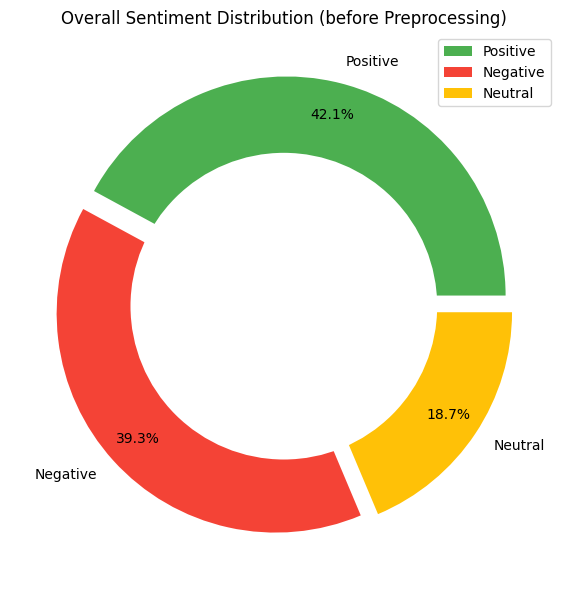

In [16]:
import matplotlib.pyplot as plt


sentiment_counts = df["sentiment_label"].value_counts()

sizes = sentiment_counts.values
labels = sentiment_counts.index

color_map = {
    "Positive": "#4CAF50",
    "Negative": "#F44336",
    "Neutral": "#FFC107"
}


colors = [color_map[label] for label in labels]


explode = [0.05] * len(labels)

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors[:len(labels)],
    autopct='%1.1f%%',
    pctdistance=0.85,
    explode=explode
)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Overall Sentiment Distribution (before Preprocessing)")

plt.legend(labels, loc="upper right")

plt.tight_layout()
plt.show()

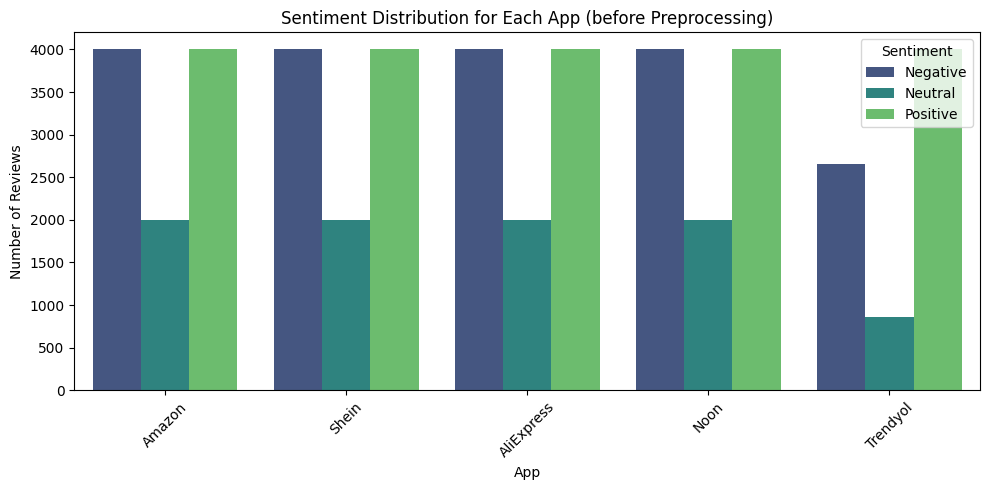

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

df_before = df.copy()
plt.figure(figsize=(10,5))

sns.countplot(
    x="app_name",
    hue="sentiment_label",
    data=df_before,
    palette="viridis"
)

plt.title("Sentiment Distribution for Each App (before Preprocessing)")
plt.xlabel("App")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [18]:
print ("Before: \n", df_before["sentiment_label"]. value_counts ())

Before: 
 sentiment_label
Positive    20000
Negative    18659
Neutral      8866
Name: count, dtype: int64


In [19]:
df = df[df["review_text"].astype(str).str.contains(r"[A-Za-z]", na=False)].copy()
df["review_text"] = df["review_text"].astype(str)
df = df[df["review_text"].str.strip().ne("")].copy()

print("After language/empty filtering:", len(df))

After language/empty filtering: 45101


In [20]:
import re



def clean_text(text):

    text = re.sub(r"http\S+", "", str(text))

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = text.lower()

    return text



df["clean_review"] = df["review_text"].apply(clean_text)

In [21]:
df[["review_text", "clean_review"]].head(10)

,review_text,clean_review
0,no way to talk to someone about fake charges,no way to talk to someone about fake charges
1,stop harassing me to join prime ! i don't want...,stop harassing me to join prime i dont want it
2,What's with no longer seeing the map when trac...,whats with no longer seeing the map when track...
3,"Unable to cancel free Prime trial! Oh, I can f...",unable to cancel free prime trial oh i can fol...
4,might just cancel Amazon after this experience...,might just cancel amazon after this experience...
5,I don't know how they could make this app any ...,i dont know how they could make this app any w...
6,terrible idea,terrible idea
7,STICK TO LOCAL SHOPPING BEFORE YOU BET ANYTHIN...,stick to local shopping before you bet anythin...
8,Since the AI takes a role. Some problems canno...,since the ai takes a role some problems cannot...
9,not working properly,not working properly


In [22]:
import nltk
nltk.download('punkt')
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [23]:
df["Tokens"]= df["clean_review"].apply(word_tokenize)
df[[ "clean_review","Tokens"]].head(5)

,clean_review,Tokens
0,no way to talk to someone about fake charges,"[no, way, to, talk, to, someone, about, fake, ..."
1,stop harassing me to join prime i dont want it,"[stop, harassing, me, to, join, prime, i, dont..."
2,whats with no longer seeing the map when track...,"[whats, with, no, longer, seeing, the, map, wh..."
3,unable to cancel free prime trial oh i can fol...,"[unable, to, cancel, free, prime, trial, oh, i..."
4,might just cancel amazon after this experience...,"[might, just, cancel, amazon, after, this, exp..."


In [24]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk


nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
negation_words = {'no', 'not', 'nor', 'never', 'neither'}
stop_words = stop_words - negation_words
lemmatizer = WordNetLemmatizer()

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df["Tokens_No_Stopwords"] = df["Tokens"].apply(remove_stopwords)


def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df["Tokens_No_Stopwords_Lemmatized"] = df["Tokens_No_Stopwords"].apply(lemmatize_tokens)


df[["Tokens", "Tokens_No_Stopwords", "Tokens_No_Stopwords_Lemmatized"]].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,Tokens,Tokens_No_Stopwords,Tokens_No_Stopwords_Lemmatized
0,"[no, way, to, talk, to, someone, about, fake, ...","[no, way, talk, someone, fake, charges]","[no, way, talk, someone, fake, charge]"
1,"[stop, harassing, me, to, join, prime, i, dont...","[stop, harassing, join, prime, dont, want]","[stop, harassing, join, prime, dont, want]"
2,"[whats, with, no, longer, seeing, the, map, wh...","[whats, no, longer, seeing, map, tracking, ord...","[whats, no, longer, seeing, map, tracking, ord..."
3,"[unable, to, cancel, free, prime, trial, oh, i...","[unable, cancel, free, prime, trial, oh, follo...","[unable, cancel, free, prime, trial, oh, follo..."
4,"[might, just, cancel, amazon, after, this, exp...","[might, cancel, amazon, experience, purchased,...","[might, cancel, amazon, experience, purchased,..."


In [25]:
df['tokens_str'] = df['Tokens_No_Stopwords_Lemmatized'].apply(lambda x: ' '.join(x))

df = df.groupby('sentiment_label', group_keys=False).apply(
    lambda x: x.drop_duplicates(subset='tokens_str')
).reset_index(drop=True)


/tmp/ipykernel_2223/3770974851.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('sentiment_label', group_keys=False).apply(


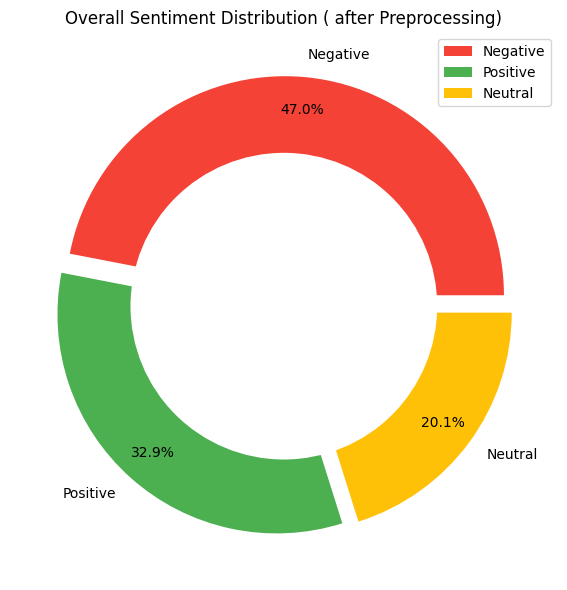

In [26]:

sentiment_counts = df["sentiment_label"].value_counts()

sizes = sentiment_counts.values
labels = sentiment_counts.index

color_map = {
    "Positive": "#4CAF50",
    "Negative": "#F44336",
    "Neutral": "#FFC107"
}


colors = [color_map[label] for label in labels]


explode = [0.05] * len(labels)

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors[:len(labels)],
    autopct='%1.1f%%',
    pctdistance=0.85,
    explode=explode
)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Overall Sentiment Distribution ( after Preprocessing)")

plt.legend(labels, loc="upper right")

plt.tight_layout()
plt.show()

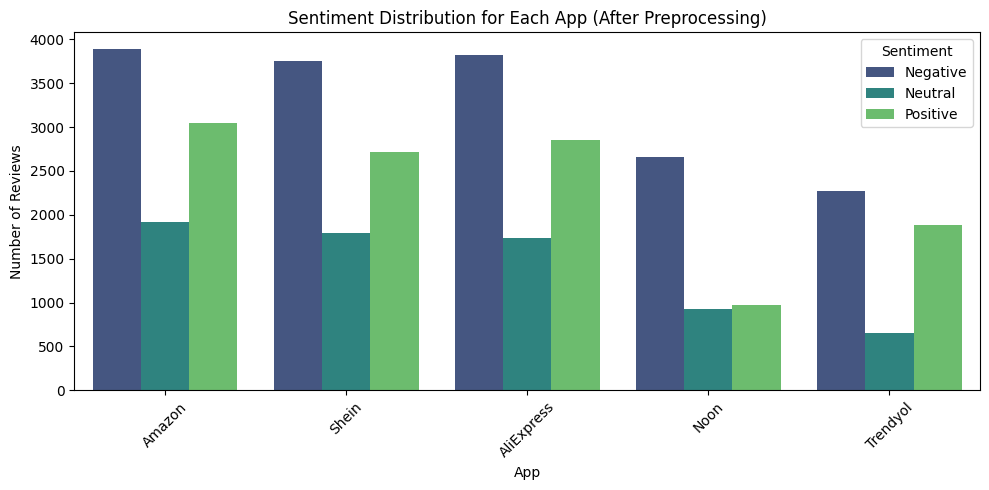

In [27]:
df_after = df.copy()

plt.figure(figsize=(10,5))

sns.countplot(
    x="app_name",
    hue="sentiment_label",
    data=df_after,
    palette="viridis"
)

plt.title("Sentiment Distribution for Each App (After Preprocessing)")
plt.xlabel("App")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [28]:

print("\nAfter:\n", df_after["sentiment_label"].value_counts() )


After:
 sentiment_label
Negative    16386
Positive    11478
Neutral      7030
Name: count, dtype: int64


In [29]:
df.to_csv("google_play_app_reviews.csv", index=False)

In [30]:
from google.colab import files
files.download("google_play_app_reviews.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 11.3 MB/s eta 0:00:00


In [32]:
X_text = df['tokens_str']
y = df['sentiment_label']

from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(X_train_text)
X_test  = vectorizer.transform(X_test_text)

In [33]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())

Before SMOTE: sentiment_label
Negative    13109
Positive     9182
Neutral      5624
Name: count, dtype: int64
After SMOTE: sentiment_label
Neutral     13109
Positive    13109
Negative    13109
Name: count, dtype: int64


In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_resampled, y_train_resampled)

rf_predictions = rf_model.predict(X_test)


print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))
print("Classification Report:\n", classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.6486602665138272
Classification Report:
               precision    recall  f1-score   support

    Negative       0.69      0.79      0.74      3277
     Neutral       0.32      0.21      0.26      1406
    Positive       0.71      0.72      0.71      2296

    accuracy                           0.65      6979
   macro avg       0.57      0.57      0.57      6979
weighted avg       0.62      0.65      0.63      6979



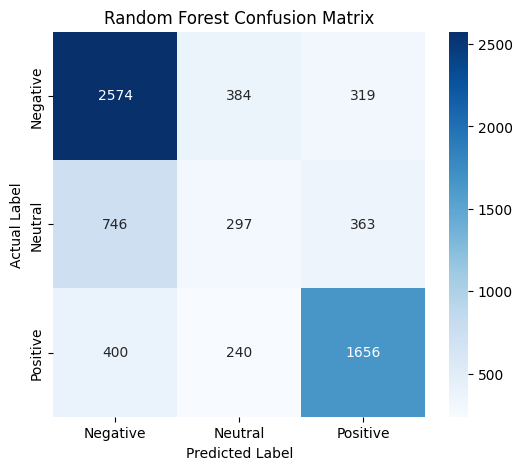

In [35]:

cm_rf = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [36]:
from sklearn.tree import DecisionTreeClassifier




dt_model = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=3,
    random_state=42
)

dt_model.fit(X_train_resampled, y_train_resampled)


y_pred = dt_model.predict(X_test)



print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.569995701389884

Classification Report:

              precision    recall  f1-score   support

    Negative       0.67      0.65      0.66      3277
     Neutral       0.26      0.27      0.26      1406
    Positive       0.63      0.65      0.64      2296

    accuracy                           0.57      6979
   macro avg       0.52      0.52      0.52      6979
weighted avg       0.57      0.57      0.57      6979



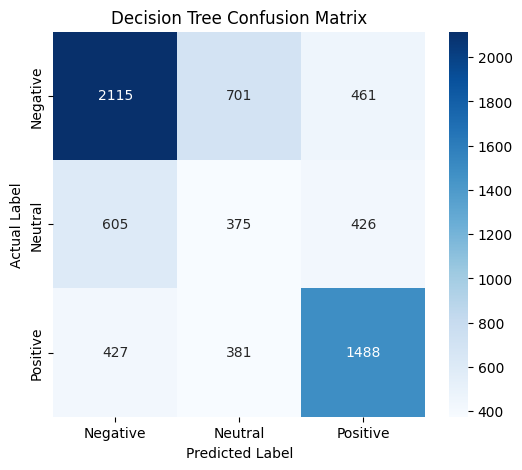

In [37]:
cm_rf = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [38]:

from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_resampled, y_train_resampled)

y_pred_SVM = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_SVM))
print("\nClassification Report:\n", classification_report(y_test, y_pred_SVM))


SVM Accuracy: 0.6321822610689211

Classification Report:
               precision    recall  f1-score   support

    Negative       0.74      0.70      0.72      3277
     Neutral       0.32      0.37      0.34      1406
    Positive       0.71      0.70      0.71      2296

    accuracy                           0.63      6979
   macro avg       0.59      0.59      0.59      6979
weighted avg       0.65      0.63      0.64      6979



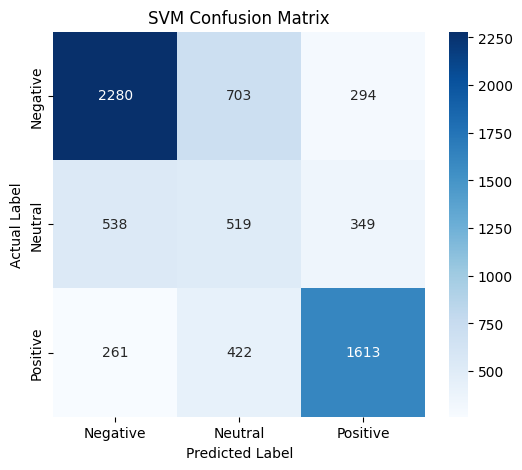

In [39]:
cm_svm = confusion_matrix(y_test, y_pred_SVM)

plt.figure(figsize=(6,5))
sns.heatmap(cm_svm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=svm_model.classes_,
            yticklabels=svm_model.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("SVM Confusion Matrix")
plt.show()

In [40]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_resampled, y_train_resampled)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.6389167502507522

Classification Report:
               precision    recall  f1-score   support

    Negative       0.73      0.68      0.71      3277
     Neutral       0.35      0.45      0.39      1406
    Positive       0.75      0.69      0.72      2296

    accuracy                           0.64      6979
   macro avg       0.61      0.61      0.61      6979
weighted avg       0.66      0.64      0.65      6979



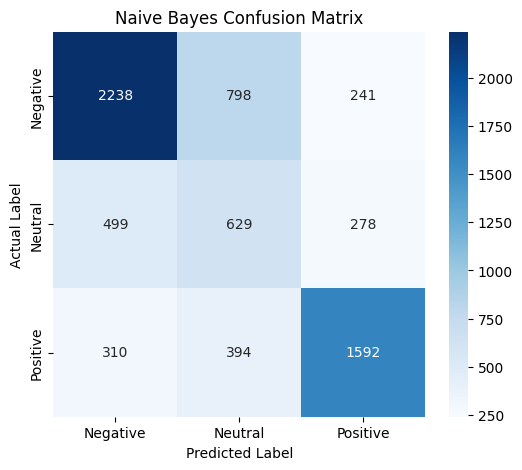

In [41]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))
sns.heatmap(cm_nb,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=nb_model.classes_,
            yticklabels=nb_model.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [42]:
!pip install xgboost

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

le = LabelEncoder()
y_train_resampled_encoded = le.fit_transform(y_train_resampled)
y_test_encoded = le.transform(y_test)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_resampled, y_train_resampled_encoded)

y_pred_xgb = xgb_model.predict(X_test)

print('XGBoost Accuracy:', accuracy_score(y_test_encoded, y_pred_xgb))
print('\nClassification Report:\n')
print(classification_report(y_test_encoded, y_pred_xgb, target_names=le.classes_))


XGBoost Accuracy: 0.6344748531308211

Classification Report:

              precision    recall  f1-score   support

    Negative       0.73      0.71      0.72      3277
     Neutral       0.31      0.36      0.33      1406
    Positive       0.73      0.69      0.71      2296

    accuracy                           0.63      6979
   macro avg       0.59      0.59      0.59      6979
weighted avg       0.65      0.63      0.64      6979



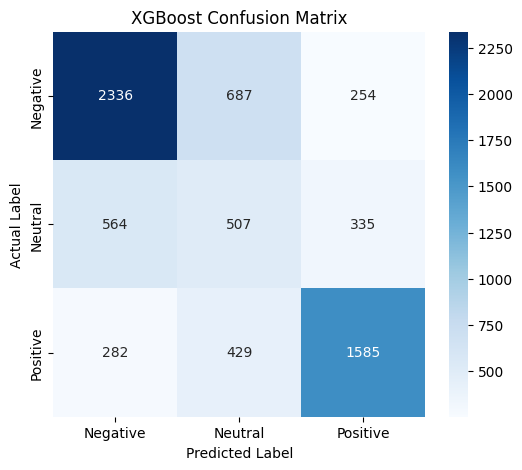

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test_encoded, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [44]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model_results = {
    "Algorithm": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1-score": []
}

def add_results(name, y_true, y_pred):
    model_results["Algorithm"].append(name)
    model_results["Accuracy"].append(accuracy_score(y_true, y_pred))
    model_results["Precision"].append(precision_score(y_true, y_pred, average='macro'))
    model_results["Recall"].append(recall_score(y_true, y_pred, average='macro'))
    model_results["F1-score"].append(f1_score(y_true, y_pred, average='macro'))

add_results("Random Forest", y_test, rf_predictions)
add_results("Decision Tree", y_test, y_pred)
add_results("SVM", y_test, y_pred_SVM)
add_results("Naive Bayes", y_test, y_pred_nb)
add_results("XGBoost", y_test_encoded, y_pred_xgb)

results_df = pd.DataFrame(model_results)
results_df

,Algorithm,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.648660,0.574236,0.572655,0.568575
1,Decision Tree,0.569996,0.518658,0.520068,0.519185
2,SVM,0.632182,0.590392,0.589139,0.588820
3,Naive Bayes,0.638917,0.611351,0.607897,0.606701
4,XGBoost,0.634475,0.591862,0.587925,0.589089


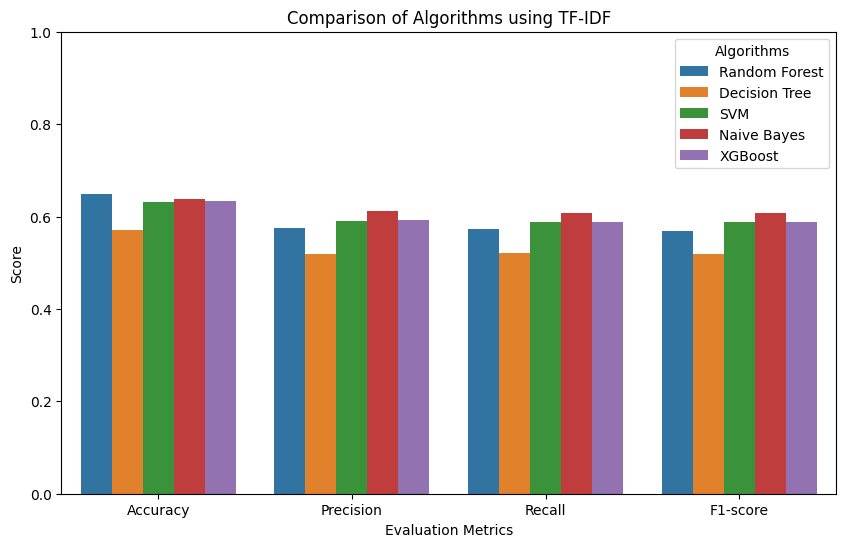

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.DataFrame(model_results)

results_melted = results_df.melt(id_vars="Algorithm",
                                 var_name="Metric",
                                 value_name="Score")

plt.figure(figsize=(10,6))

sns.barplot(data=results_melted,
            x="Metric",
            y="Score",
            hue="Algorithm")

plt.title("Comparison of Algorithms using TF-IDF")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")

plt.ylim(0,1)

plt.legend(title="Algorithms")

plt.show()

In [49]:
joblib.dump(nb_model, 'sentiment_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
print('Model and Vectorizer saved successfully')


Model and Vectorizer saved successfully


In [51]:
model = joblib.load('sentiment_model.pkl')
vectorizer = joblib.load('tfidf_vectorizer.pkl')

sample = [
    'This product is amazing',
    'I ordered one product but they send wrong item i cannot contact seller also customer service 0 please dont download this one',
]
vec = vectorizer.transform(sample)
prediction = model.predict(vec)
print('Prediction:', prediction)
# 2 inputs -> 2 outputs


Prediction: ['Positive' 'Negative']


In [52]:
from google.colab import files
files.download('sentiment_model.pkl')
files.download('tfidf_vectorizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [53]:
print(df.columns.tolist())
print(df.shape)

['app_name', 'review_text', 'rating', 'sentiment_label', 'clean_review', 'Tokens', 'Tokens_No_Stopwords', 'Tokens_No_Stopwords_Lemmatized', 'tokens_str']
(34894, 9)
